In [1]:
from PIL import Image
import matplotlib.pyplot as plt

def pixelate(image, block_size):
    width, height = image.size
    num_blocks_x = width // block_size
    num_blocks_y = height // block_size

    # Resize the image to the desired size
    small_image = image.resize((num_blocks_x, num_blocks_y), resample=Image.BOX)
    # Scale the image back up to the original size
    pixelated_image = small_image.resize(image.size, resample=Image.NEAREST)

    return pixelated_image

# Load the image
image_path = 'B.png'
image = Image.open(image_path)

# Define the block size (adjust as needed)
block_size = 4

# Pixelate the image
pixelated_image = pixelate(image, block_size)
plt.imshow(pixelated_image, cmap="gray")

FileNotFoundError: [Errno 2] No such file or directory: 'B.png'

In [6]:
directory_path = "./numbers/Font"

In [9]:
import os
os.listdir(directory_path)

['alphabet', 'number']

In [25]:
def pixelate_image(image, block_size):
    width, height = image.size
    num_blocks_x = width // block_size
    num_blocks_y = height // block_size

    # Resize the image to the desired size
    small_image = image.resize((num_blocks_x, num_blocks_y), resample=Image.BOX)
    # Scale the image back up to the original size
    pixelated_image = small_image.resize(image.size, resample=Image.NEAREST)

    return pixelated_image

def pixelate_images_in_directory(directory, block_size=4):
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                image = Image.open(file_path)
                pixelated_image = pixelate_image(image, block_size)
                pixelated_image.save(file_path)
            except IOError:
                print(f"Unable to open or save image: {file_path}")

# Directory containing the subdirectories of images
main_directory = "./numbers/Font"

# Pixelation block size (adjust as needed)
block_size = 4

# Iterate through the subdirectories and pixelate images
for subdirectory in ['alphabet', 'number']:
    subdirectory_path = os.path.join(main_directory, subdirectory)
    if os.path.isdir(subdirectory_path):
        pixelate_images_in_directory(subdirectory_path, block_size)

In [24]:
os.path.isdir("./alphabet")

False

In [29]:
!pip install torchvision

Alphabet

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 10

# Data preprocessing and augmentation
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert to grayscale
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load the dataset
dataset = ImageFolder('./numbers/Font/alphabet', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define the convolutional neural network
class AlphabetClassifier(nn.Module):
    def __init__(self):
        super(AlphabetClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(32 * 32 * 32, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 26)  # 26 output classes for alphabets

    def quantize(self, a, total_bits = 32):
        integer_format = 1+torch.ceil(torch.log2(torch.abs(a+1)))*(a>=0) + torch.ceil(torch.log2(torch.abs(a)))*(a<0)
        fractional_format = total_bits - integer_format
        x = torch.div(torch.floor(a * 2**fractional_format), 2**fractional_format)
        return x

    def forward(self, x, quant=False):
        if(quant == True):
            x = self.quantize(x)
        # convolve
        x = self.conv1(x)
        # batchnorm
        x = self.bn1(x)
        # quantize
        if(quant == True):
            x = self.quantize(x)
        # relu
        x = self.relu1(x)
        # pool
        x = self.pool1(x)
        x = self.conv2(x)
        if(quant == True):
            x = self.quantize(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        if(quant == True):
            x = self.quantize(x)
        x = self.relu3(x)
        x = self.fc2(x)
        if(quant == True):
            x = self.quantize(x)
        return x

# Initialize the model
model = AlphabetClassifier()

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
total_step = len(dataloader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(dataloader):
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print training progress
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{total_step}], Loss: {loss.item():.4f}')

# Save the model
torch.save(model.state_dict(), 'alphabet_classifier.pth')


Device: cpu
Epoch [1/10], Step [100/826], Loss: 0.5399
Epoch [1/10], Step [200/826], Loss: 0.7661
Epoch [1/10], Step [300/826], Loss: 0.5319
Epoch [1/10], Step [400/826], Loss: 0.2938
Epoch [1/10], Step [500/826], Loss: 0.0858
Epoch [1/10], Step [600/826], Loss: 0.2480
Epoch [1/10], Step [700/826], Loss: 0.0697
Epoch [1/10], Step [800/826], Loss: 0.1713
Epoch [2/10], Step [100/826], Loss: 0.0309
Epoch [2/10], Step [200/826], Loss: 0.0528
Epoch [2/10], Step [300/826], Loss: 0.0255
Epoch [2/10], Step [400/826], Loss: 0.6666
Epoch [2/10], Step [500/826], Loss: 0.0374
Epoch [2/10], Step [600/826], Loss: 0.4059
Epoch [2/10], Step [700/826], Loss: 0.1279
Epoch [2/10], Step [800/826], Loss: 0.0060
Epoch [3/10], Step [100/826], Loss: 0.0042
Epoch [3/10], Step [200/826], Loss: 0.0371
Epoch [3/10], Step [300/826], Loss: 0.0028
Epoch [3/10], Step [400/826], Loss: 0.0399
Epoch [3/10], Step [500/826], Loss: 0.0105
Epoch [3/10], Step [600/826], Loss: 0.0023
Epoch [3/10], Step [700/826], Loss: 0.0223

Number

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 5

# Data preprocessing and augmentation
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert to grayscale
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the dataset
dataset = ImageFolder('./numbers/Font/number', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define the convolutional neural network
class NumberClassifier(nn.Module):
    def __init__(self):
        super(NumberClassifier, self).__init__()
        self.bn1 = nn.BatchNorm2d(16)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(32 * 32 * 32, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)  # 10 output classes for numbers

    def quantize(self, a, total_bits = 32):
        integer_format = 1+torch.ceil(torch.log2(torch.abs(a+1)))*(a>=0) + torch.ceil(torch.log2(torch.abs(a)))*(a<0)
        fractional_format = total_bits - integer_format
        x = torch.div(torch.floor(a * 2**fractional_format), 2**fractional_format)
        return x

    def forward(self, x, quant=False):
        if(quant == True):
            x = self.quantize(x)
        x = self.conv1(x)
        x = self.bn1(x)
        if(quant == True):
            x = self.quantize(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        if(quant == True):
            x = self.quantize(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        if(quant == True):
            x = self.quantize(x)
        x = self.relu3(x)
        x = self.fc2(x)
        if(quant == True):
            x = self.quantize(x)
        return x

# Initialize the model
model = NumberClassifier()

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
total_step = len(dataloader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(dataloader):
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print training progress
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{total_step}], Loss: {loss.item():.4f}')

# Save the model
torch.save(model.state_dict(), 'number_classifier.pth')


Epoch [1/5], Step [100/318], Loss: 0.2594
Epoch [1/5], Step [200/318], Loss: 0.0396
Epoch [1/5], Step [300/318], Loss: 0.0113
Epoch [2/5], Step [100/318], Loss: 0.0100
Epoch [2/5], Step [200/318], Loss: 0.0360
Epoch [2/5], Step [300/318], Loss: 0.0128
Epoch [3/5], Step [100/318], Loss: 0.0088
Epoch [3/5], Step [200/318], Loss: 0.0026
Epoch [3/5], Step [300/318], Loss: 0.0030
Epoch [4/5], Step [100/318], Loss: 0.0029
Epoch [4/5], Step [200/318], Loss: 0.0016
Epoch [4/5], Step [300/318], Loss: 0.0119
Epoch [5/5], Step [100/318], Loss: 0.0001
Epoch [5/5], Step [200/318], Loss: 0.0000
Epoch [5/5], Step [300/318], Loss: 0.0000


In [36]:
import cv2
image = cv2.imread("./numbers/Font/alphabet/A/img011-00001.png")


image.shape

(128, 128, 3)

In [61]:
import socket

# Data to be sent
cameraId = "camera1"
detected = True
numberPlate = "ABC123"

# Format the data
requestData = {
    cameraId : "camera1",
    detected : True,
    numberPlate : "ABC123"
}

# Endpoint details
host = "https://codehackerone-friendly-space-lamp-xxw6vjr9xgq36g74-5100.preview.app.github.dev/"
port = 5100

# Create a socket
client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)

try:
    # Connect to the server
    client_socket.connect((host, port))

    # Send data to the server
    client_socket.sendall(requestData.encode())

    # Receive response from the server
    response = client_socket.recv(1024)
    print("Response:", response.decode())

except ConnectionRefusedError:
    print("Error: Connection refused. Make sure the server is running.")

finally:
    # Close the socket connection
    client_socket.close()


gaierror: [Errno 11001] getaddrinfo failed

In [2]:
!pip install imutils

  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25860 sha256=6087dd9880569cf396aefd8374df4bc954067e54d01e6da859b2b1d4efa3cf12
  Stored in directory: c:\users\bhatt\appdata\local\pip\cache\wheels\59\1b\52\0dea905f8278d5514dc4d0be5e251967f8681670cadd3dca89
Successfully built imutils


## alphanumeric

In [1]:
import cv2
import imutils
# import pytesseract
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.filters import gaussian
import matplotlib.patches as mpatches
from skimage.measure import label, regionprops
from skimage.util import invert
from scipy.spatial.distance import euclidean
import cv2

def crop_image(car):
    image=car
    gray_img=[]
    # print(car.shape)
    if car.shape[2] == 3:
        gray_img = rgb2gray(car)
    else:
        gray_img = rgb2gray(rgba2rgb(car))

    #blur the image to remove any noise
    blurred_gray_img = gaussian(gray_img)
    # plt.figure(figsize=(20,20))
    # plt.axis("off")
    # plt.imshow(blurred_gray_img, cmap="gray")

    thresh = threshold_otsu(gray_img)
    # print(thresh)
    thresh = 0.46
    binary = invert(gray_img > thresh)

    label_image = label(binary, connectivity=2)
    for region in regionprops(label_image):
        minr, minc, maxr, maxc = region.bbox
        rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                  fill=False, edgecolor='red', linewidth=2)

    # fig, ax = plt.subplots(figsize=(10, 6))
    # ax.imshow(blurred_gray_img, cmap="gray")

    text_like_regions = []
    for region in regionprops(label_image):
        minr, minc, maxr, maxc = region.bbox
        w = maxc - minc
        h = maxr - minr

        asr = w/h

        region_area = w*h

        wid,hei = blurred_gray_img.shape
        img_area = wid*hei

        # The aspect ratio is less than 1 to eliminate highly elongated regions
        # The size of the region should be greater than 15 pixels but smaller than 1/5th of the image
        # dimension to be considered for further processing
        if region_area > img_area/5000 and region_area < (0.2 * img_area) and asr < 1 and h > w:
          #print(w, h, i, region.area, region.bbox)
          text_like_regions.append(region)

    all_points = []
    for region in text_like_regions:
        minr, minc, maxr, maxc = region.bbox
        rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                fill=False, edgecolor='red', linewidth=2)
        # ax.add_patch(rect)
        circ = mpatches.Circle((minc, minr), radius=5)
        # ax.add_patch(circ)
        all_points.append([minc, minr, maxc, maxr])



    # Define the threshold for ymin, ymax difference and area similarity
    y_threshold = 5  # Adjust this value as needed
    area_similarity_threshold = 0.5  # Adjust this value as needed

    # Sort the list of bounding boxes based on ymin (y-coordinate)
    sorted_boxes = sorted(all_points, key=lambda box: box[1])

    # Initialize variables
    groups = []
    current_group = []

    # Iterate over the sorted boxes
    for box in sorted_boxes:
        if not current_group:
            current_group.append(box)
        else:
            prev_box = current_group[-1]
            ymin_diff = abs(box[1] - prev_box[1])
            ymax_diff = abs(box[3] - prev_box[3])
            #area_similarity = abs((box[2] - box[0]) * (box[3] - box[1]) - (prev_box[2] - prev_box[0]) * (prev_box[3] - prev_box[1]))

            if ymin_diff <= y_threshold and ymax_diff <= y_threshold :
                current_group.append(box)
            else:
                if len(current_group) >= 10:
                    groups.append(current_group[:10])  # Extract the first 10 bounding boxes
                current_group = [box]

    # Check if the last group satisfies the condition
    if len(current_group) >= 10:
        groups.append(current_group[:10])  # Extract the first 10 bounding boxes


    license_plate_coords = sorted(groups[0], key=lambda box: box[1], reverse=True)

    # Perform OCR on each license plate coordinate
    output_lp = []
    for idx, coords in enumerate(license_plate_coords):
        # Crop the license plate region
        xmin, ymin, xmax, ymax = coords
        license_plate = image[ymin:ymax, xmin:xmax]
        output_lp.append((license_plate, idx))

#         print(license_plate.shape)
#         print(idx)
#         plt.imshow(license_plate, cmap="gray")
#         plt.show()

    return output_lp

In [2]:
import numpy as np
car = imread('test2.jpg')
x = crop_image(car)
x_np = np.array(x)
print("shape ->", x_np.shape)

shape -> (10, 2)


<ipython-input-2-070875592bd0>:4: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_np = np.array(x)


In [3]:
from PIL import Image

def expand_image(image, target_size=(128,128)):
    img = Image.fromarray(image)  # Convert numpy array to PIL Image
    img = img.resize(target_size, resample=Image.BICUBIC)  # Resize the image
    expanded_image = np.array(img)  # Convert PIL Image back to numpy array
    return expanded_image

In [4]:
exp = expand_image(image = x_np[0][0])
type(exp)

numpy.ndarray

In [5]:
exp.shape

(128, 128, 3)

In [23]:
import tensorflow as tf


In [27]:
meta_graph_path = 'my_model.meta'  # Replace with the path to your .meta file
sess = tf.Session()
saver = tf.train.import_meta_graph(meta_graph_path)

AttributeError: module 'tensorflow' has no attribute 'Session'

In [26]:
checkpoint_dir = 'store'  # Replace with the path to the directory containing the checkpoint files
checkpoint_path = tf.train.latest_checkpoint(checkpoint_dir)
saver.restore(sess, checkpoint_path)


NameError: name 'saver' is not defined

In [1]:
import tensorflow as tf
from tensorflow.keras import layers

# Define the model
model_alpha = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(26, activation='softmax')  # Assuming 26 alphabets
])

# Compile the model
model_alpha.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model_alpha.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 64)                3

In [ ]:
import os
import string
import cv2
import numpy as np

image_directory = './numbers/Font/alphabet/'
SIZE = 128
dataset, label = [], []
# mapping dict
label_dict = {}
for i in range(26):
    label_dict[chr(ord('A') + i)] = i

for it in list(string.ascii_uppercase):
    # for loop from 'a' to 'z'
    curr_imgs = os.listdir(image_directory + it + '/')
    for i, image_name in enumerate(curr_imgs):
        # goes through the images of every folder
        if (image_name.split('.')[1] == 'png'):
            image = cv2.imread(image_directory + it + '/' + image_name)
            image = cv2.resize(image, (SIZE, SIZE))
            if image.shape[2] != 3:
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            # shape = 128, 128, 3
            dataset.append(np.array(image))
            label.append(label_dict[it])

dataset, label = np.array(dataset), np.array(label)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset, label, test_size = 0.20, random_state = 0)

X_train = X_train /255.
X_test = X_test /255.

from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Train the model
history = model_alpha.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate the model
test_loss, test_accuracy = model_alpha.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Save the model
model_alpha.save('model_alpha.h5')

In [2]:
import os

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'alphabet_classifier.pth',
 'car.jpg',
 'd2.jpg',
 'download.png',
 'my_model.meta',
 'numbers',
 'numbers.zip',
 'number_classifier.pth',
 'store',
 'test1.jpeg',
 'test2.jpg',
 'test3.jpg',
 'test4.jpg',
 'test5.jpeg',
 'test7.png',
 'test8.JPG',
 'test9.jpg',
 'training and etc.ipynb',
 'Untitled.ipynb']

In [31]:
import cv2
import imutils
# import pytesseract
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.filters import gaussian
import matplotlib.patches as mpatches
from skimage.measure import label, regionprops
from skimage.util import invert
from scipy.spatial.distance import euclidean
import cv2
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model


def get_plate(img_path):
  # read the image and convert it to grayscale
  car = imread(img_path)
  #car = img_path
  gray_img=[]
  print(car.shape)
  if car.shape[2] == 3:
    gray_img = rgb2gray(car)
  else:
    gray_img = rgb2gray(rgba2rgb(car))

  #blur the image to remove any noise
  blurred_gray_img = gaussian(gray_img)

  thresh = threshold_otsu(gray_img)
  print(thresh)
  thresh = 0.46
  binary = invert(gray_img > thresh)
  label_image = label(binary, connectivity=2)  

  for region in regionprops(label_image):
      minr, minc, maxr, maxc = region.bbox
      rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                fill=False, edgecolor='red', linewidth=2)
      


  text_like_regions = []
  for region in regionprops(label_image):
      minr, minc, maxr, maxc = region.bbox
      w = maxc - minc
      h = maxr - minr

      asr = w/h

      region_area = w*h

      wid,hei = blurred_gray_img.shape
      img_area = wid*hei

      # The aspect ratio is less than 1 to eliminate highly elongated regions
      # The size of the region should be greater than 15 pixels but smaller than 1/5th of the image
      # dimension to be considered for further processing
      if region_area > img_area/5000 and region_area < (0.2 * img_area) and asr < 1 and h > w:
          #print(w, h, i, region.area, region.bbox)
          text_like_regions.append(region)

  all_points = []
  for region in text_like_regions:
      minr, minc, maxr, maxc = region.bbox
      rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                fill=False, edgecolor='red', linewidth=2)
      circ = mpatches.Circle((minc, minr), radius=5)
      all_points.append([minc, minr, maxc, maxr])

  # Define the threshold for ymin, ymax difference and area similarity
  y_threshold = 5  # Adjust this value as needed
  area_similarity_threshold = 0.5  # Adjust this value as needed

  # Sort the list of bounding boxes based on ymin (y-coordinate)
  sorted_boxes = sorted(all_points, key=lambda box: box[1])

  # Initialize variables
  groups = []
  current_group = []

  # Iterate over the sorted boxes
  for box in sorted_boxes:
      if not current_group:
          current_group.append(box)
      else:
          prev_box = current_group[-1]
          ymin_diff = abs(box[1] - prev_box[1])
          ymax_diff = abs(box[3] - prev_box[3])
          #area_similarity = abs((box[2] - box[0]) * (box[3] - box[1]) - (prev_box[2] - prev_box[0]) * (prev_box[3] - prev_box[1]))

          if ymin_diff <= y_threshold and ymax_diff <= y_threshold :
              current_group.append(box)
          else:
              if len(current_group) >= 10:
                  groups.append(current_group[:10])  # Extract the first 10 bounding boxes
              current_group = [box]

  # Check if the last group satisfies the condition
  if len(current_group) >= 10:
      groups.append(current_group[:10])  # Extract the first 10 bounding boxes

  groups = sorted(groups[0], key=lambda box: box[0])


  alpha = load_model('model_alpha.h5', compile=False)
  num = load_model('model_num.h5', compile=False)
  predictions = []
  # Load the image containing the license plate
  image_path = img_path
  image = cv2.imread(image_path)

  # Define the license plate coordinates
  license_plate_coords = groups

  # Perform OCR on each license plate coordinate
  for index, coords in enumerate(license_plate_coords):
      # Crop the license plate region
      xmin, ymin, xmax, ymax = coords
      license_plate = image[ymin:ymax, xmin:xmax]
      license_plate = cv2.resize(license_plate, (128, 128))
      # Preprocess the image
      #x = preprocess_input(license_plate)
      # Add an extra dimension to represent the batch size
      x = np.expand_dims(license_plate, axis=0)

      if index in [0, 1, 4, 5]:
        prediction = np.argmax(alpha.predict(x))
        predictions.append(chr(ord('A') + prediction))
      else:
        prediction = np.argmax(num.predict(x))
        predictions.append(prediction)

  string_array = [str(item) for item in predictions]
  return "".join(string_array)

In [32]:
get_plate("d2.jpg")

(768, 1024, 3)
0.380859375


'HF71JE7011'

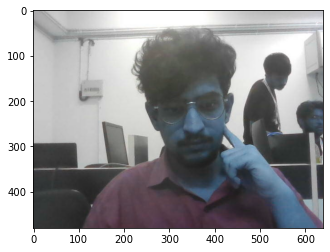

(480, 640, 3)
0.5428688947610294
list index out of range



UnboundLocalError: local variable 'consistent_outputs' referenced before assignment

In [36]:
import cv2
from datetime import datetime
import time
import sched
import os
# import tensorflow as tf
import requests


def predict_string(image):
    return "AB12CD4567"
def check_consistency(text, length):
    return len(text) == length

# Load the machine learning model from .h5 file
# model = tf.keras.models.load_model('model.h5')

# Create a scheduler
scheduler = sched.scheduler(time.time, time.sleep)

# Define constants
CONSISTENT_OUTPUT_THRESHOLD = 3
API_ENDPOINT = "http://example.com/api"


# Function to capture image, generate string prediction, and make API call
def capture_predict_and_call_api(sc):
    cap = cv2.VideoCapture(0)
    ret, frame = cap.read()
    
    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    filename = f"image.jpg"
    
    cv2.imwrite(filename, frame)
    image = cv2.imread(filename)
    
    prediction = ""
    
    plt.imshow(image, cmap="gray")
    plt.show()
    
    try:
        prediction = get_plate(filename)
    except Exception as e:
        prediction = ""
        print(str(e))
        
    print(prediction)
    consistent = check_consistency(prediction, 10)
    
    if consistent:
        api_data = {
            'predictions': consistent_outputs
        }
        # response = requests.post(API_ENDPOINT, json=api_data)
        # print(response.text)
        print("making API call")
        consistent_outputs = []
        consecutive_consistent_outputs = 0
        time.sleep(5)
    
    # Schedule the next capture and prediction
    scheduler.enter(1, 1, capture_predict_and_call_api, (sc,))

# Start the scheduler
scheduler.enter(1, 1, capture_predict_and_call_api, (scheduler,))
scheduler.run()